Import Libraries

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os

Image Upload

Upload your image


Saving spelunky.png to spelunky.png

Image uploaded: spelunky.png


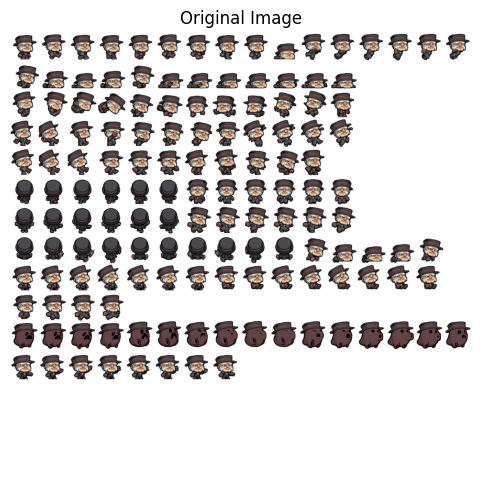

In [ ]:
print("Upload your image")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print(f"\nImage uploaded: {filename}")
original = cv2.imread(filename)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.show()

Convert to Grayscale

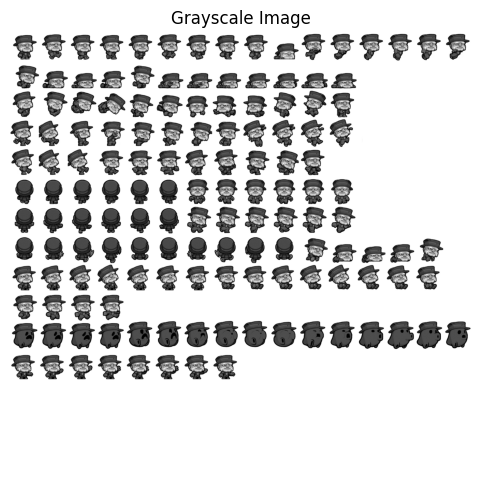

In [ ]:
gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()

Low-Pass Filter

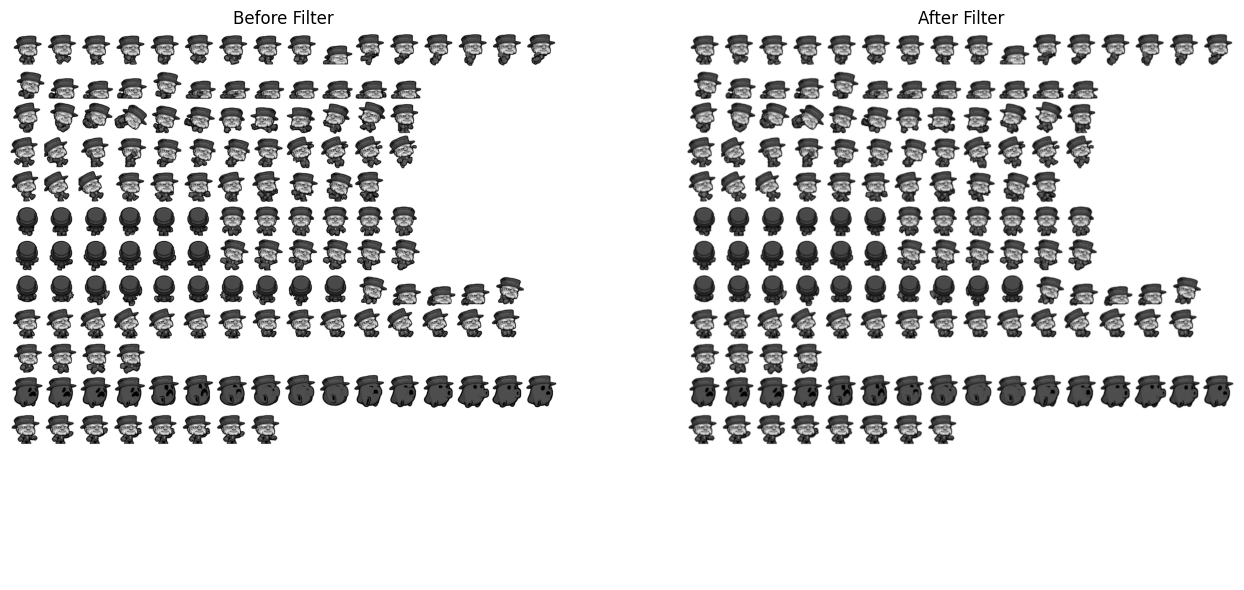

In [ ]:
kernel_size = (5, 5)
blurred = cv2.GaussianBlur(gray, kernel_size, 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Before Filter')
axes[0].axis('off')

axes[1].imshow(blurred, cmap='gray')
axes[1].set_title('After Filter')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Threshold via Otsu White

Threshold value: 159.00


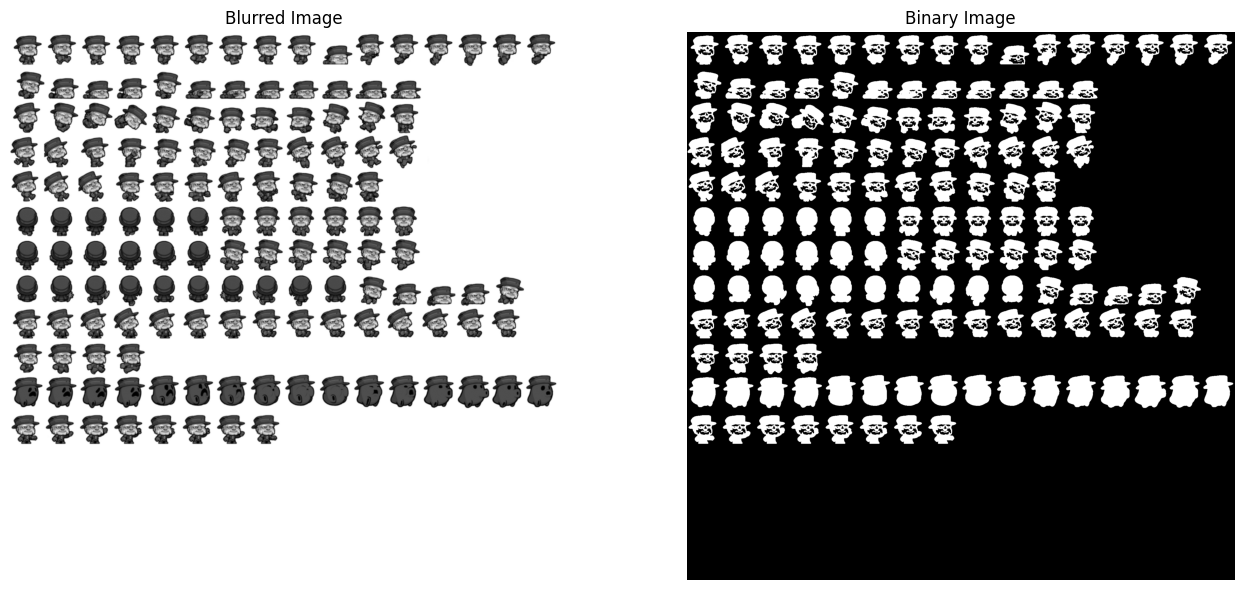

In [ ]:
threshold_value, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print(f"Threshold value: {threshold_value:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(blurred, cmap='gray')
axes[0].set_title('Blurred Image')
axes[0].axis('off')

axes[1].imshow(binary, cmap='gray')
axes[1].set_title(f'Binary Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Morphological Operations

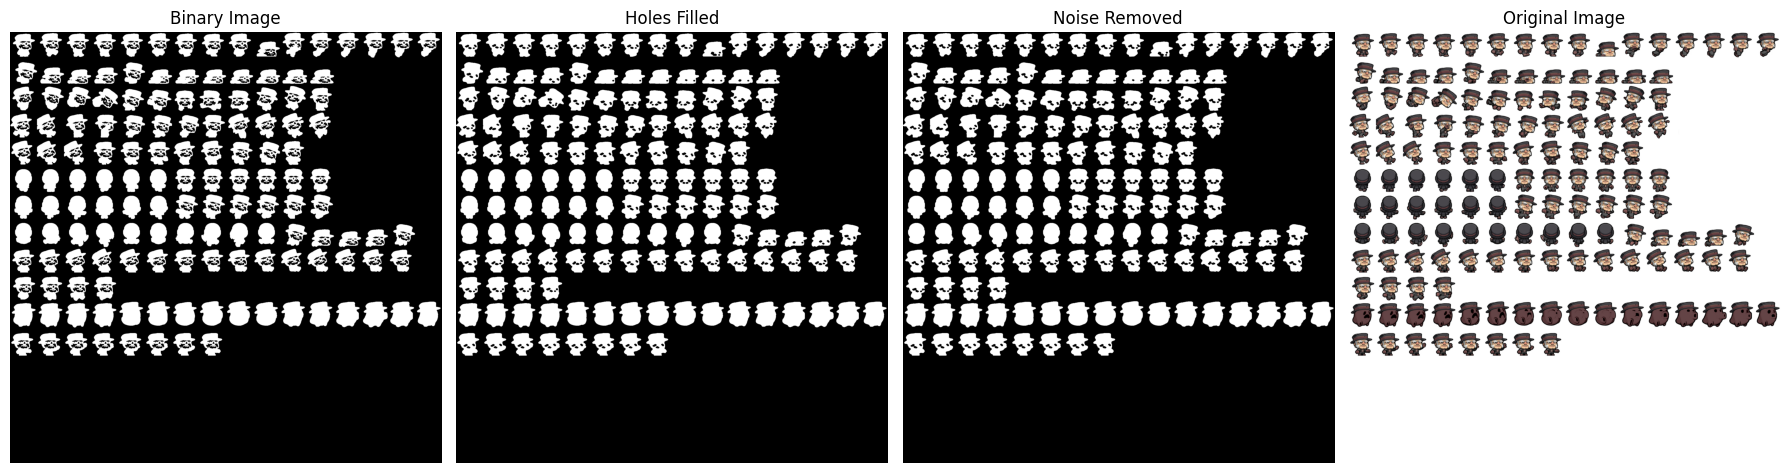

In [ ]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=2)
cleaned = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel, iterations=1)

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

axes[0].imshow(binary, cmap='gray')
axes[0].set_title('Binary Image')
axes[0].axis('off')

axes[1].imshow(closed, cmap='gray')
axes[1].set_title('Holes Filled')
axes[1].axis('off')

axes[2].imshow(cleaned, cmap='gray')
axes[2].set_title('Noise Removed')
axes[2].axis('off')

axes[3].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[3].set_title('Original Image')
axes[3].axis('off')

plt.tight_layout()
plt.show()

Connected Components

Number of components: 145


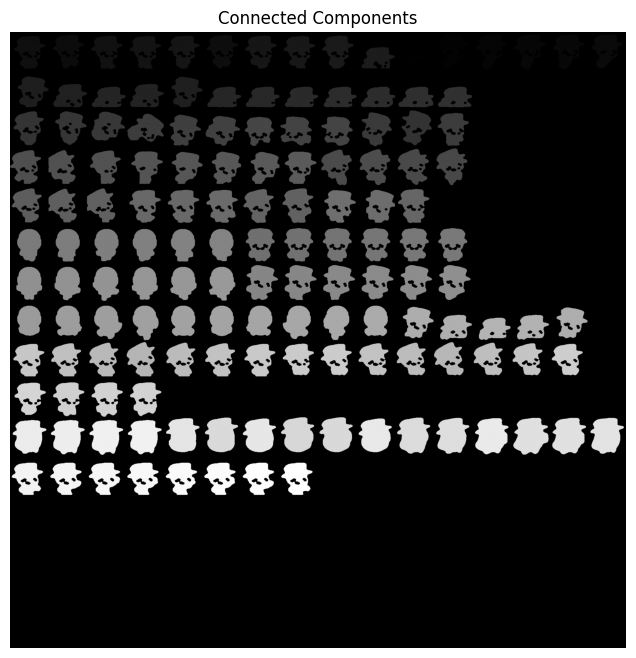

In [ ]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(cleaned, connectivity=8)
num_components = num_labels - 1

print(f"Number of components: {num_components}")
labeled_gray = np.zeros_like(labels, dtype=np.uint8)

step = 255 // num_components
for label in range(1, num_labels):
    gray_value = label * step
    labeled_gray[labels == label] = gray_value

plt.figure(figsize=(10, 8))
plt.imshow(labeled_gray, cmap='gray')
plt.title(f'Connected Components')
plt.axis('off')
plt.show()

Drawing Contours

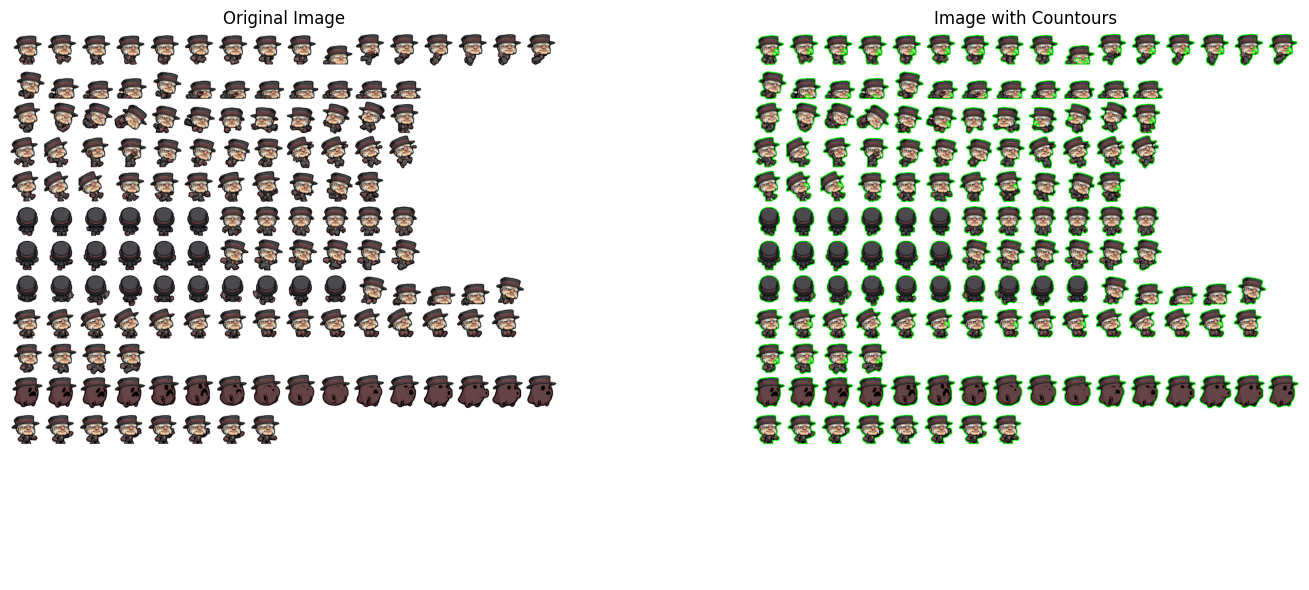

In [ ]:
contours, hierarchy = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contour_image = original.copy()
cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
axes[1].set_title(f'Image with Contours')
axes[1].axis('off')

plt.tight_layout()
plt.show()

ROI Extraction

Number of ROIs found: 145


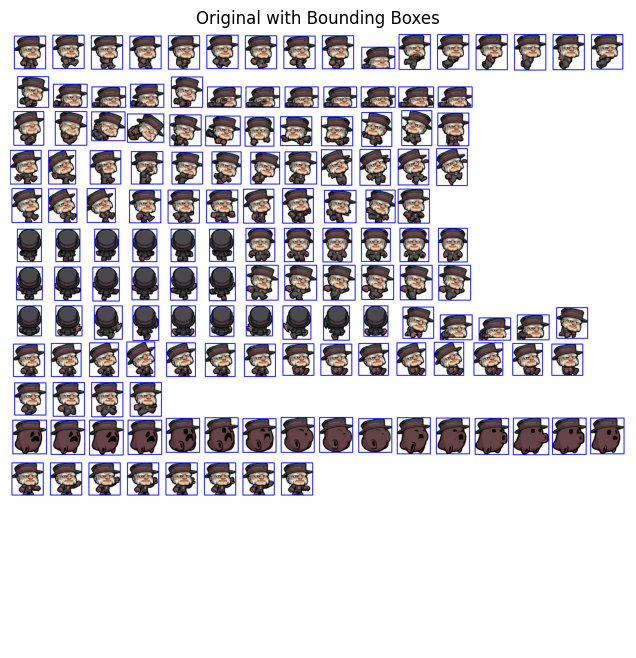

In [ ]:
roi_images = []
bbox_image = original.copy()

for i, contour in enumerate(contours):
    x, y, w, h = cv2.boundingRect(contour)
    cv2.rectangle(bbox_image, (x, y), (x + w, y + h), (255, 0, 0), 2)
    roi = original[y:y+h, x:x+w]
    roi_images.append(roi)

print(f"Number of ROIs found: {len(roi_images)}")

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(bbox_image, cv2.COLOR_BGR2RGB))
plt.title(f'Original with Bounding Boxes')
plt.axis('off')
plt.show()

File Saving

In [ ]:
output_dir = "roi_output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created output directory: {output_dir}/")

base_name = os.path.splitext(filename)[0]

cv2.imwrite(f"{output_dir}/{base_name}_1_grayscale.png", gray)
cv2.imwrite(f"{output_dir}/{base_name}_2_blurred.png", blurred)
cv2.imwrite(f"{output_dir}/{base_name}_3_binary.png", binary)
cv2.imwrite(f"{output_dir}/{base_name}_4_morphology.png", cleaned)
cv2.imwrite(f"{output_dir}/{base_name}_5_connected_components.png", labeled_gray)
cv2.imwrite(f"{output_dir}/{base_name}_6_contours.png", contour_image)
cv2.imwrite(f"{output_dir}/{base_name}_7_bounding_boxes.png", bbox_image)

for i, roi in enumerate(roi_images):
    roi_filename = f"{output_dir}/{base_name}_ROI_{i+1:03d}.png"
    cv2.imwrite(roi_filename, roi)

In [ ]:
import shutil

zip_filename = f"{base_name}_ROI_results"
shutil.make_archive(zip_filename, 'zip', output_dir)

print(f"\nCreated ZIP file: {zip_filename}.zip")

files.download(f"{zip_filename}.zip")


Created ZIP file: mario_ROI_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>